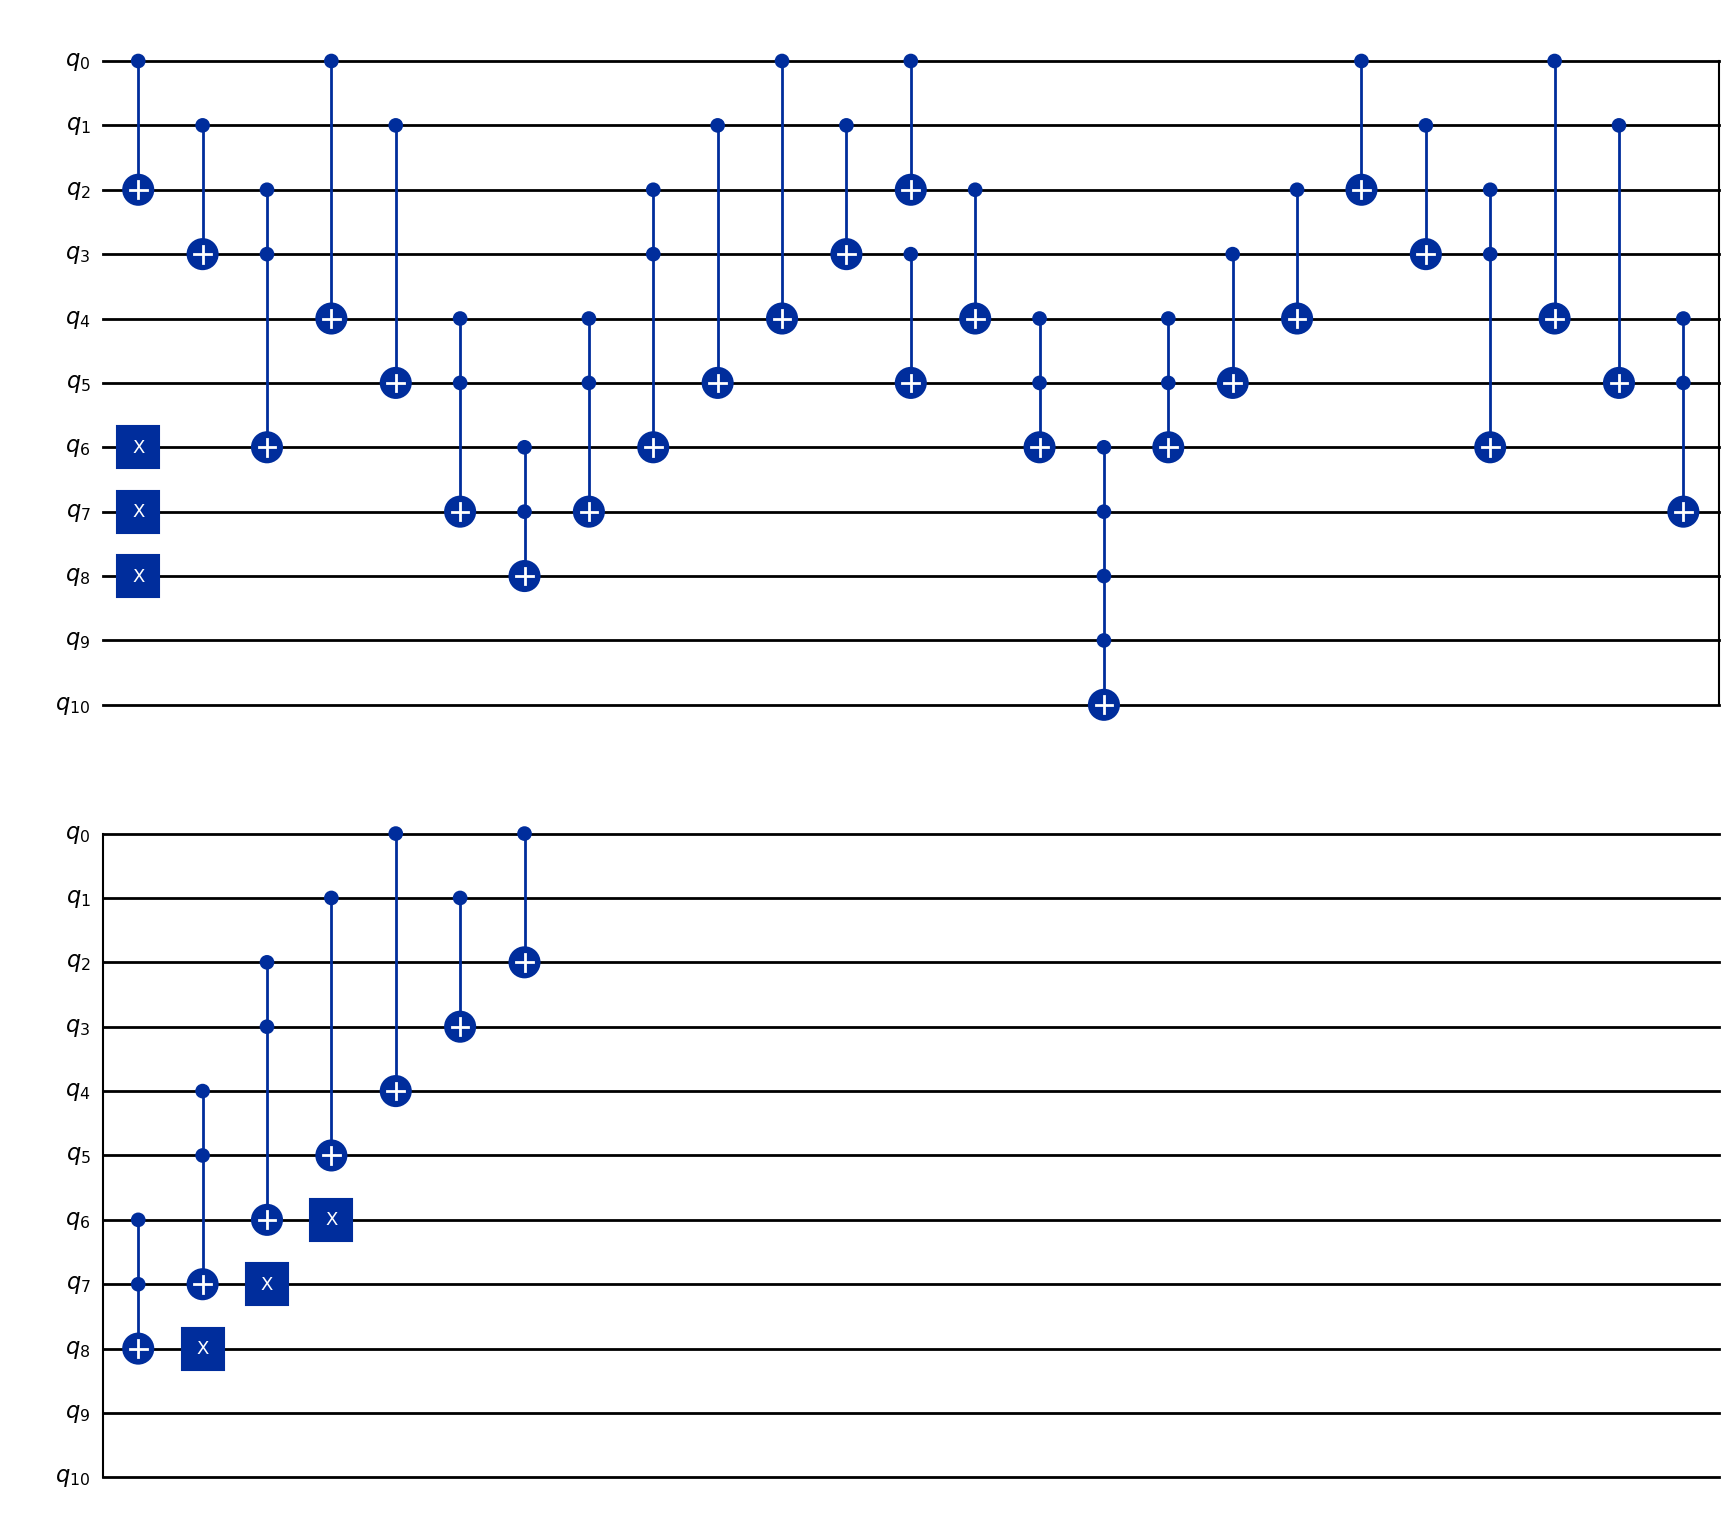

In [2]:
from qiskit import *

qc = QuantumCircuit(11, name="k3_saha")

qc.x(6)
qc.x(7)
qc.x(8)

qc.cx(0,2)
qc.cx(1,3)
# qc.x(2)
# qc.x(3)
qc.ccx(2,3,6)

qc.cx(0,4)
qc.cx(1,5)
# qc.x(4)
# qc.x(5)
qc.ccx(4,5,7)

qc.ccx(6,7,8)

qc.ccx(4,5,7)
# qc.x(5)
# qc.x(4)
qc.cx(1,5)
qc.cx(0,4)

qc.ccx(2,3,6)
# qc.x(3)
# qc.x(2)
qc.cx(1,3)
qc.cx(0,2)

qc.cx(2,4)
qc.cx(3,5)
# qc.x(4)
# qc.x(5)
qc.ccx(4,5,6)

qc.mcx([6,7,8,9], 10)

qc.ccx(4,5,6)
# qc.x(5)
# qc.x(4)
qc.cx(3,5)
qc.cx(2,4)

qc.cx(0,2)
qc.cx(1,3)
# qc.x(2)
# qc.x(3)
qc.ccx(2,3,6)

qc.cx(0,4)
qc.cx(1,5)
# qc.x(4)
# qc.x(5)
qc.ccx(4,5,7)

qc.ccx(6,7,8)

qc.ccx(4,5,7)
# qc.x(5)
# qc.x(4)
qc.cx(1,5)
qc.cx(0,4)

qc.ccx(2,3,6)
# qc.x(3)
# qc.x(2)
qc.cx(1,3)
qc.cx(0,2)

qc.x(6)
qc.x(7)
qc.x(8)

qc.draw("mpl")

In [5]:
qc.depth()

19

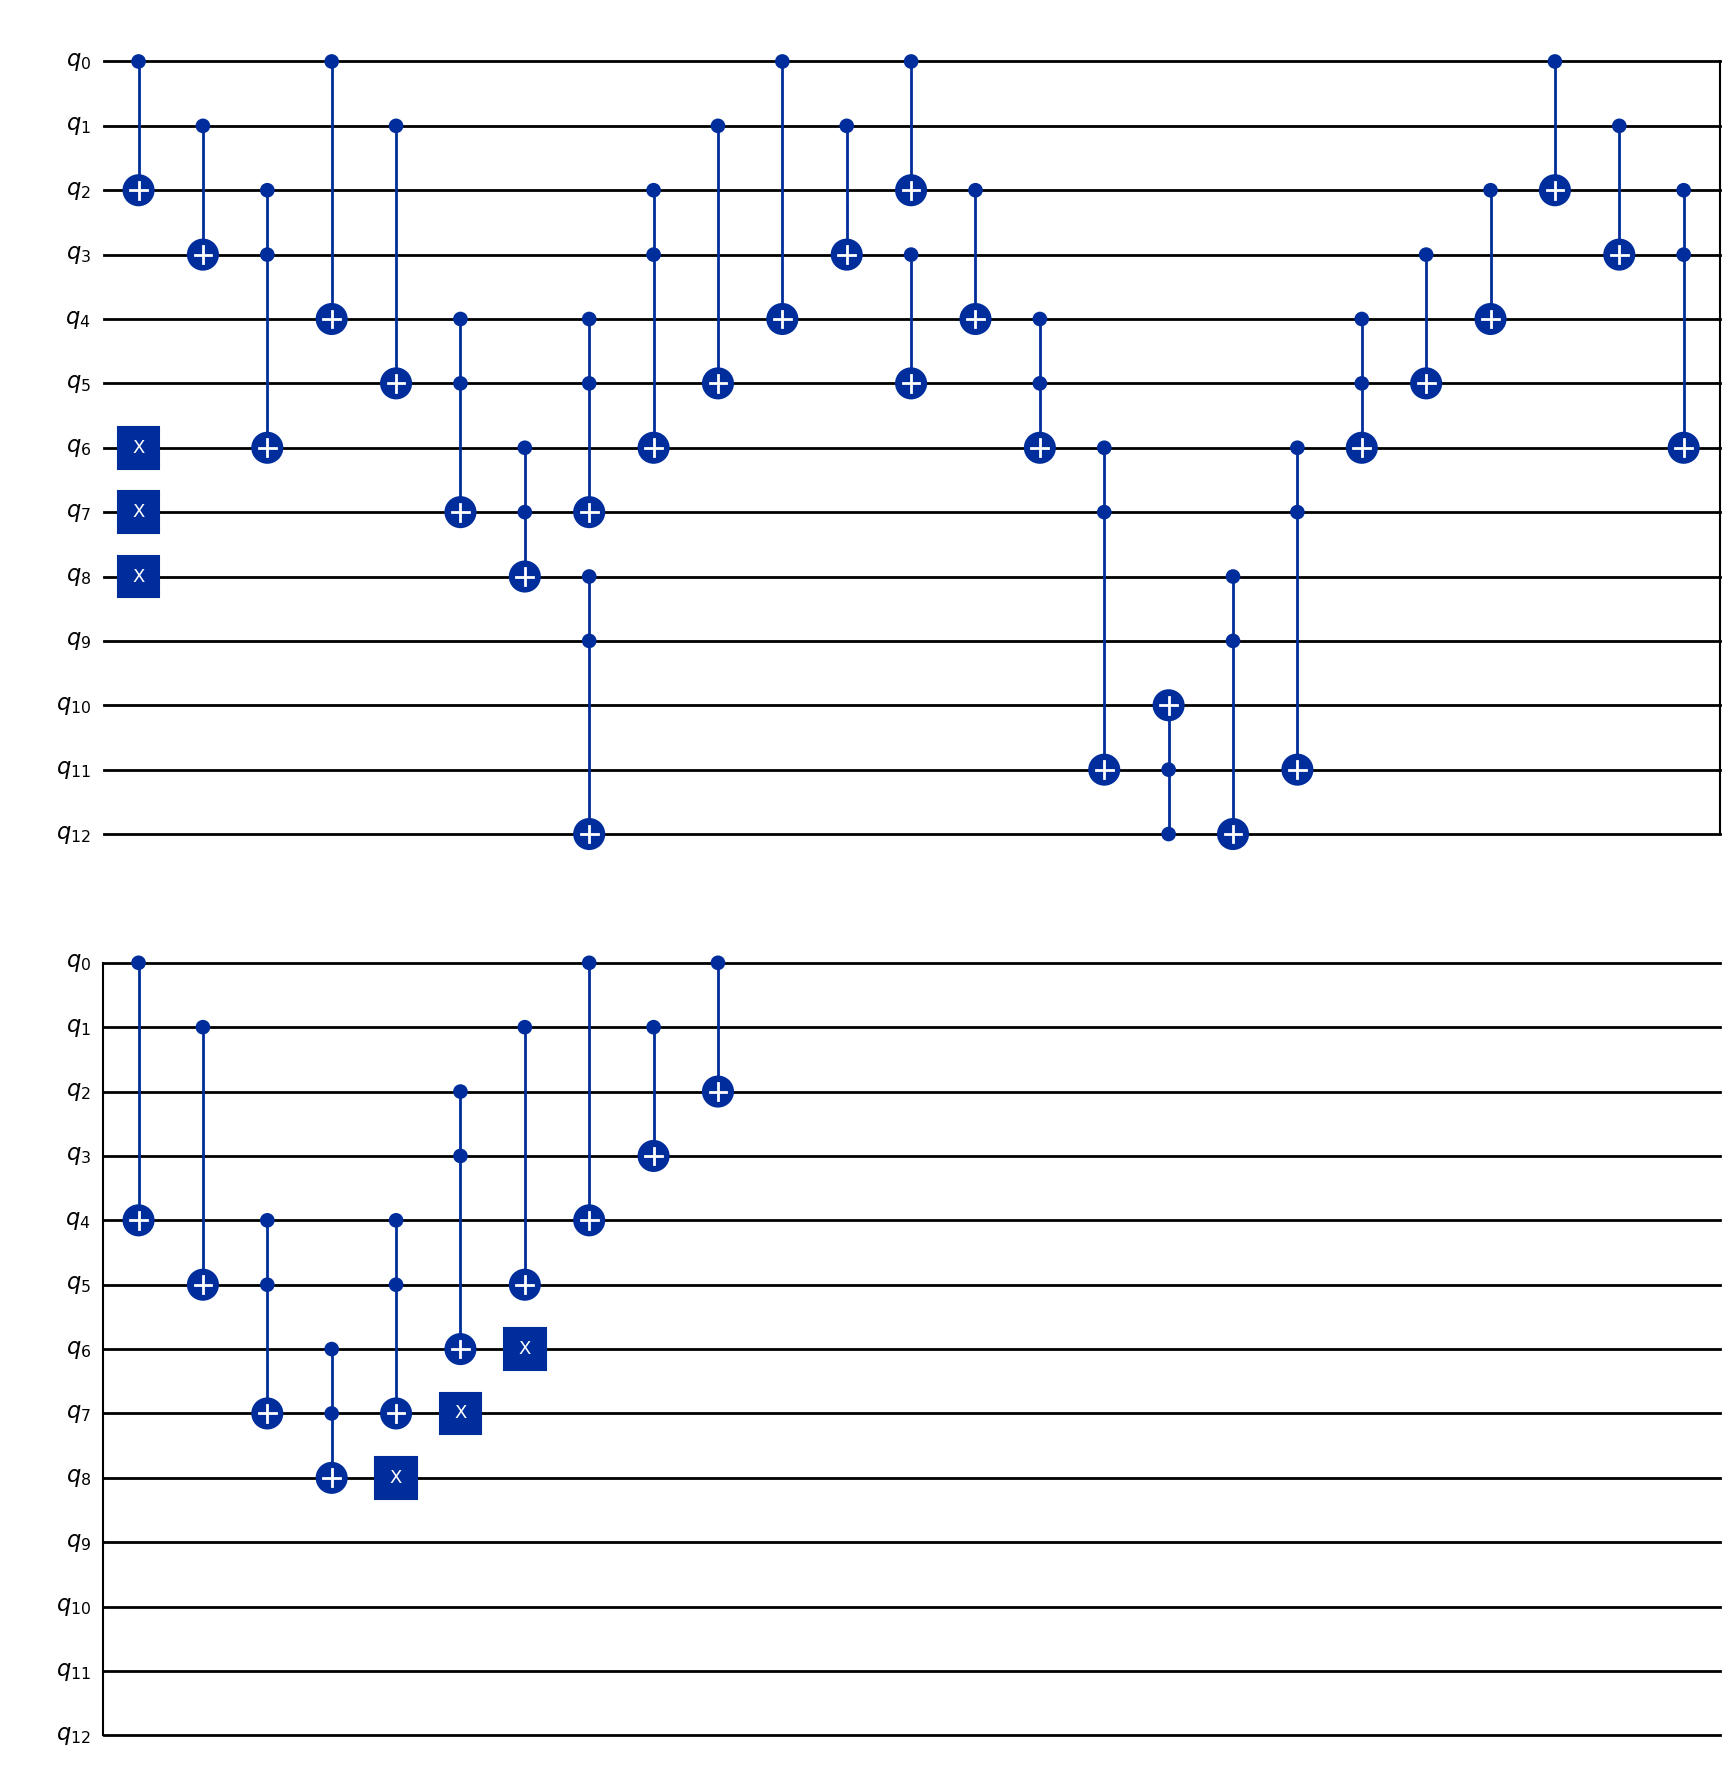

In [3]:
# Replace the line: qc.mcx([6,7,8,9], 10)
# with the following decomposition:

# MCX decomposition for 4-controlled X gate on qubits [6,7,8,9] -> 10
# Using clean ancilla qubits (we'll need 2 additional qubits)

# First, let's create a larger circuit to accommodate ancilla qubits
qc_decomposed = QuantumCircuit(13, name="k3_saha_decomposed")  # Added 2 ancilla qubits (11, 12)

# Copy all gates before MCX
qc_decomposed.x(6)
qc_decomposed.x(7)
qc_decomposed.x(8)

qc_decomposed.cx(0,2)
qc_decomposed.cx(1,3)
qc_decomposed.ccx(2,3,6)

qc_decomposed.cx(0,4)
qc_decomposed.cx(1,5)
qc_decomposed.ccx(4,5,7)

qc_decomposed.ccx(6,7,8)

qc_decomposed.ccx(4,5,7)
qc_decomposed.cx(1,5)
qc_decomposed.cx(0,4)

qc_decomposed.ccx(2,3,6)
qc_decomposed.cx(1,3)
qc_decomposed.cx(0,2)

qc_decomposed.cx(2,4)
qc_decomposed.cx(3,5)
qc_decomposed.ccx(4,5,6)

# MCX decomposition starts here
# 4-controlled X gate: controls=[6,7,8,9], target=10
# Using ancilla qubits 11 and 12

# Forward pass
qc_decomposed.ccx(6, 7, 11)    # First Toffoli: controls 6,7 -> ancilla 11
qc_decomposed.ccx(8, 9, 12)    # Second Toffoli: controls 8,9 -> ancilla 12
qc_decomposed.ccx(11, 12, 10)  # Final Toffoli: ancilla 11,12 -> target 10

# Backward pass (to uncompute ancillas)
qc_decomposed.ccx(8, 9, 12)    # Uncompute ancilla 12
qc_decomposed.ccx(6, 7, 11)    # Uncompute ancilla 11

# MCX decomposition ends here

# Continue with remaining gates
qc_decomposed.ccx(4,5,6)
qc_decomposed.cx(3,5)
qc_decomposed.cx(2,4)

qc_decomposed.cx(0,2)
qc_decomposed.cx(1,3)
qc_decomposed.ccx(2,3,6)

qc_decomposed.cx(0,4)
qc_decomposed.cx(1,5)
qc_decomposed.ccx(4,5,7)

qc_decomposed.ccx(6,7,8)

qc_decomposed.ccx(4,5,7)
qc_decomposed.cx(1,5)
qc_decomposed.cx(0,4)

qc_decomposed.ccx(2,3,6)
qc_decomposed.cx(1,3)
qc_decomposed.cx(0,2)

qc_decomposed.x(6)
qc_decomposed.x(7)
qc_decomposed.x(8)

qc_decomposed.draw("mpl")

In [4]:
qc_decomposed.depth()

21